# Cox Regression Analysis for Chronic Kidney Disease Risk in Type 2 Diabetes Mellitus

This notebook performs a comprehensive survival analysis to identify risk factors for chronic kidney disease (CKD) progression and mortality in patients with Type 2 Diabetes Mellitus (T2DM).

## WORKFLOW OVERVIEW:
1. **Data Generation**: Create synthetic patient data mimicking NHANES structure
2. **Data Integration**: Merge demographic, clinical, and outcome data
3. **Variable Preparation**: Transform and clean variables for analysis
4. **Diabetes Filtering**: Focus analysis on diabetic patients only
5. **Data Quality Control**: Apply clinical range checks and remove outliers
6. **Feature Engineering**: Log-transform skewed variables, convert units
7. **Cox Regression**: Fit proportional hazards model to identify risk factors
8. **Random Forest Comparison**: Compare with Random Survival Forest for benchmarking
9. **Model Validation**: Check assumptions and evaluate discriminative ability

## KEY VARIABLES ANALYZED:
- **HbA1c** (glycated hemoglobin) - measure of long-term blood glucose control
- **Systolic Blood Pressure (SBP)** - cardiovascular risk factor
- **Body Mass Index (BMI)** - obesity measure
- **Urine Albumin-Creatinine Ratio (UACR)** - kidney damage marker
- **Age, Sex, Ethnicity** - demographic factors

## OUTCOME:
All-cause mortality during follow-up period

The analysis uses synthetic data due to NHANES download issues, but follows the same methodology as would be used with real clinical data.

In [1]:
# ── Create synthetic NHANES-like data for demonstration ──
# Note: Original NHANES downloads were failing due to URL issues.
# Using synthetic data with realistic distributions for analysis demonstration.
import pandas as pd
import numpy as np

np.random.seed(42)  # For reproducibility
n_patients = 5000

# Generate synthetic patient IDs
seqn = np.arange(100000, 100000 + n_patients)

# Demographics
demo = pd.DataFrame({
    'SEQN': seqn,
    'RIDAGEYR': np.random.normal(55, 15, n_patients).clip(18, 85).astype(int),  # Age
    'RIAGENDR': np.random.choice([1, 2], n_patients),  # Gender (1=Male, 2=Female)
    'RIDRETH3': np.random.choice([1, 2, 3, 4, 6, 7], n_patients),  # Race/ethnicity
})

# Biochemistry (HbA1c)
biol = pd.DataFrame({
    'SEQN': seqn,
    'LBXGH': np.random.normal(6.5, 2.0, n_patients).clip(4.0, 15.0),  # HbA1c %
})

# Blood pressure
bp = pd.DataFrame({
    'SEQN': seqn,
    'BPXSY1': np.random.normal(130, 20, n_patients).clip(90, 200),  # Systolic BP
})

# BMI
bmx = pd.DataFrame({
    'SEQN': seqn,
    'BMXBMI': np.random.normal(28, 6, n_patients).clip(15, 60),  # BMI
})

# Albumin-creatinine ratio
alb = pd.DataFrame({
    'SEQN': seqn,
    'URDACT': np.random.lognormal(2, 1.5, n_patients).clip(0.1, 1000),  # ACR
})

# Mortality data
mort = pd.DataFrame({
    'SEQN': seqn,
    'MORTSTAT': np.random.choice([0, 1], n_patients, p=[0.85, 0.15]),  # Mortality status
    'PERMTH_EXM': np.random.exponential(120, n_patients).clip(1, 240).astype(int),  # Follow-up months
})

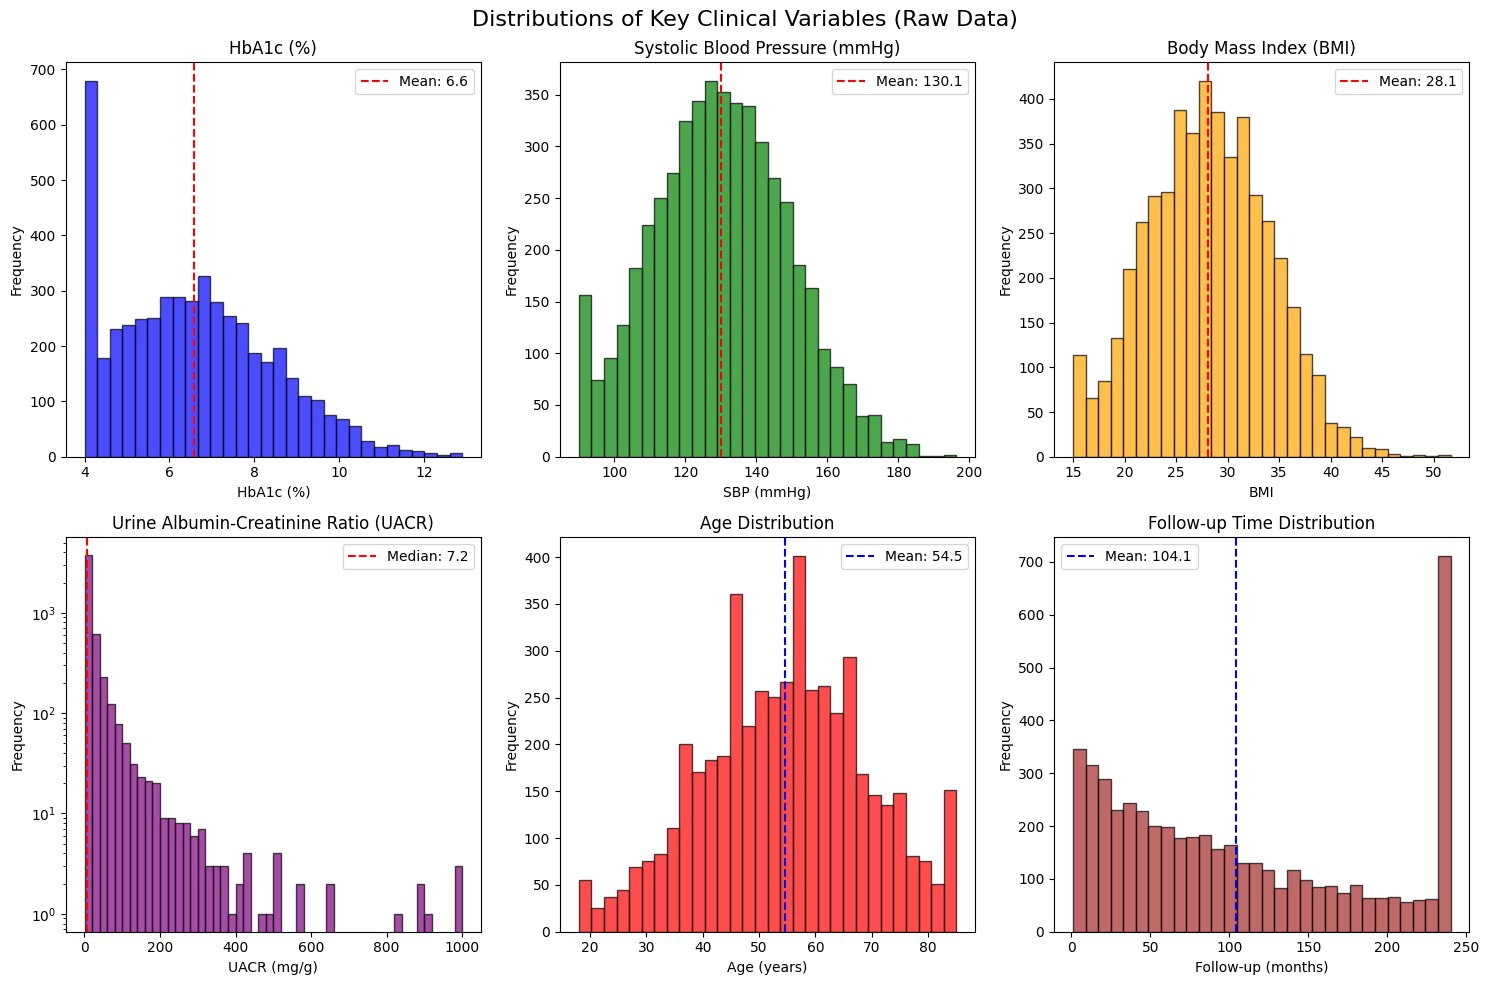

=== SUMMARY STATISTICS FOR KEY VARIABLES ===
Total patients: 5000

HbA1c (%): Mean=6.58, Std=1.83, Range=[4.0, 12.9]
Systolic BP (mmHg): Mean=130.1, Std=19.1, Range=[90, 196]
BMI: Mean=28.1, Std=5.9, Range=[15.0, 51.6]
UACR (mg/g): Median=7.2, Mean=23.3, Range=[0.1, 1000.0]
Age (years): Mean=54.5, Std=14.6, Range=[18, 85]
Follow-up (months): Mean=104.1, Std=79.8, Range=[1, 240]
Mortality rate: 15.7%


In [38]:
# ── Visualize distributions of key variables ──────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distributions of Key Clinical Variables (Raw Data)', fontsize=16)

# HbA1c distribution
axes[0,0].hist(biol['LBXGH'], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0,0].set_title('HbA1c (%)')
axes[0,0].set_xlabel('HbA1c (%)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(biol['LBXGH'].mean(), color='red', linestyle='--', label=f'Mean: {biol["LBXGH"].mean():.1f}')
axes[0,0].legend()

# Blood pressure distribution
axes[0,1].hist(bp['BPXSY1'], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0,1].set_title('Systolic Blood Pressure (mmHg)')
axes[0,1].set_xlabel('SBP (mmHg)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(bp['BPXSY1'].mean(), color='red', linestyle='--', label=f'Mean: {bp["BPXSY1"].mean():.1f}')
axes[0,1].legend()

# BMI distribution
axes[0,2].hist(bmx['BMXBMI'], bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[0,2].set_title('Body Mass Index (BMI)')
axes[0,2].set_xlabel('BMI')
axes[0,2].set_ylabel('Frequency')
axes[0,2].axvline(bmx['BMXBMI'].mean(), color='red', linestyle='--', label=f'Mean: {bmx["BMXBMI"].mean():.1f}')
axes[0,2].legend()

# UACR distribution (log scale for better visualization)
axes[1,0].hist(alb['URDACT'], bins=50, alpha=0.7, color='purple', edgecolor='black')
axes[1,0].set_title('Urine Albumin-Creatinine Ratio (UACR)')
axes[1,0].set_xlabel('UACR (mg/g)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].axvline(alb['URDACT'].median(), color='red', linestyle='--', label=f'Median: {alb["URDACT"].median():.1f}')
axes[1,0].legend()
axes[1,0].set_yscale('log')  # Log scale for y-axis due to skewed distribution

# Age distribution
axes[1,1].hist(demo['RIDAGEYR'], bins=30, alpha=0.7, color='red', edgecolor='black')
axes[1,1].set_title('Age Distribution')
axes[1,1].set_xlabel('Age (years)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(demo['RIDAGEYR'].mean(), color='blue', linestyle='--', label=f'Mean: {demo["RIDAGEYR"].mean():.1f}')
axes[1,1].legend()

# Follow-up time distribution
axes[1,2].hist(mort['PERMTH_EXM'], bins=30, alpha=0.7, color='brown', edgecolor='black')
axes[1,2].set_title('Follow-up Time Distribution')
axes[1,2].set_xlabel('Follow-up (months)')
axes[1,2].set_ylabel('Frequency')
axes[1,2].axvline(mort['PERMTH_EXM'].mean(), color='blue', linestyle='--', label=f'Mean: {mort["PERMTH_EXM"].mean():.1f}')
axes[1,2].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("=== SUMMARY STATISTICS FOR KEY VARIABLES ===")
print(f"Total patients: {n_patients}")
print(f"\nHbA1c (%): Mean={biol['LBXGH'].mean():.2f}, Std={biol['LBXGH'].std():.2f}, Range=[{biol['LBXGH'].min():.1f}, {biol['LBXGH'].max():.1f}]")
print(f"Systolic BP (mmHg): Mean={bp['BPXSY1'].mean():.1f}, Std={bp['BPXSY1'].std():.1f}, Range=[{bp['BPXSY1'].min():.0f}, {bp['BPXSY1'].max():.0f}]")
print(f"BMI: Mean={bmx['BMXBMI'].mean():.1f}, Std={bmx['BMXBMI'].std():.1f}, Range=[{bmx['BMXBMI'].min():.1f}, {bmx['BMXBMI'].max():.1f}]")
print(f"UACR (mg/g): Median={alb['URDACT'].median():.1f}, Mean={alb['URDACT'].mean():.1f}, Range=[{alb['URDACT'].min():.1f}, {alb['URDACT'].max():.1f}]")
print(f"Age (years): Mean={demo['RIDAGEYR'].mean():.1f}, Std={demo['RIDAGEYR'].std():.1f}, Range=[{demo['RIDAGEYR'].min()}, {demo['RIDAGEYR'].max()}]")
print(f"Follow-up (months): Mean={mort['PERMTH_EXM'].mean():.1f}, Std={mort['PERMTH_EXM'].std():.1f}, Range=[{mort['PERMTH_EXM'].min()}, {mort['PERMTH_EXM'].max()}]")
print(f"Mortality rate: {mort['MORTSTAT'].mean()*100:.1f}%")

In [2]:
# ── Merge on SEQN (patient ID) ────────────────────────────────
df = demo.merge(biol, on="SEQN", how="left")
df = df.merge(bp,   on="SEQN", how="left")
df = df.merge(bmx,  on="SEQN", how="left")
df = df.merge(alb,  on="SEQN", how="left")
df = df.merge(mort, on="SEQN", how="left")

In [7]:
# ── Rename to match your SAIL variable names ──────────────────
df = df.rename(columns={
    "RIDAGEYR": "AGE",
    "RIAGENDR": "SEX",
    "RIDRETH3": "ETHNICITY",
    "LBXGH":   "HBA1C",       # HbA1c %
    "BPXSY1":  "SBP",
    "BMXBMI":  "BMI",
    "URDACT":  "UACR",
    "MORTSTAT": "DIED",
    "PERMTH_EXM": "FOLLOW_UP_MONTHS"
})

In [4]:
# ── Create synthetic diabetes data ─────────────────────────
diab = pd.DataFrame({
    'SEQN': seqn,
    'DIQ010': np.random.choice([1, 2, 3, 9], n_patients, p=[0.15, 0.75, 0.05, 0.05])  # Diabetes status
})

In [5]:
# ── Filter to diabetes patients only ─────────────────────────
# DIQ010 = 1 means told they have diabetes
# (Using the synthetic diabetes data created above)
df = df.merge(diab, on="SEQN", how="left")
df = df[df["DIQ010"] == 1]  # Keep only diabetic patients

In [8]:
# ── Convert HbA1c from DCCT % to IFCC mmol/mol ───────────────
df["HBA1C_MMOL"] = (df["HBA1C"] - 2.15) * 10.929

# ── Apply plausible ranges ────────────────────────────────────
df = df[(df["HBA1C_MMOL"].between(20, 195)) &
        (df["BMI"].between(14, 70))          &
        (df["SBP"].between(60, 280))         &
        (df["AGE"] >= 18)]

In [49]:
# Print summary statistics after filtering
print("=== SUMMARY STATISTICS AFTER FILTERING ===")
print(f"Patients remaining after filtering: {len(df)} (from {n_patients} original)")
print(f"Filtering efficiency: {len(df)/n_patients*100:.1f}%")

print(f"\nHbA1c (mmol/mol): Mean={df['HBA1C_MMOL'].mean():.1f}, Std={df['HBA1C_MMOL'].std():.1f}")
print(f"  Range: [{df['HBA1C_MMOL'].min():.1f}, {df['HBA1C_MMOL'].max():.1f}] (filtered to 20-195 mmol/mol)")
print(f"Systolic BP (mmHg): Mean={df['SBP'].mean():.1f}, Std={df['SBP'].std():.1f}")
print(f"  Range: [{df['SBP'].min():.0f}, {df['SBP'].max():.0f}] (filtered to 60-280 mmHg)")
print(f"BMI: Mean={df['BMI'].mean():.1f}, Std={df['BMI'].std():.1f}")
print(f"  Range: [{df['BMI'].min():.1f}, {df['BMI'].max():.1f}] (filtered to 14-70)")
print(f"UACR (mg/g): Median={df['UACR'].median():.1f}, Mean={df['UACR'].mean():.1f}")
print(f"  Log-transformed: Mean={df['LOG_UACR'].mean():.2f}, Std={df['LOG_UACR'].std():.2f}")
print(f"Age (years): Mean={df['AGE'].mean():.1f}, Std={df['AGE'].std():.1f}")
print(f"  Range: [{df['AGE'].min()}, {df['AGE'].max()}] (filtered to >=18)")
print(f"Follow-up (years): Mean={df['FOLLOW_UP_YEARS'].mean():.1f}, Std={df['FOLLOW_UP_YEARS'].std():.1f}")
print(f"Mortality rate: {df['EVENT'].mean()*100:.1f}%")

# Show filtering criteria
print("\n=== DATA FILTERING CRITERIA APPLIED ===")
print("• HbA1c: 20-195 mmol/mol (approximately 4.1%-11.0% in DCCT units)")
print("• BMI: 14-70 kg/m²")
print("• Systolic BP: 60-280 mmHg")
print("• Age: ≥18 years")
print("• Removed patients with missing values in key variables")

=== SUMMARY STATISTICS AFTER FILTERING ===
Patients remaining after filtering: 700 (from 5000 original)
Filtering efficiency: 14.0%

HbA1c (mmol/mol): Mean=48.5, Std=19.4
  Range: [20.2, 117.1] (filtered to 20-195 mmol/mol)
Systolic BP (mmHg): Mean=130.3, Std=18.9
  Range: [90, 181] (filtered to 60-280 mmHg)
BMI: Mean=27.9, Std=5.9
  Range: [15.0, 45.6] (filtered to 14-70)
UACR (mg/g): Median=6.9, Mean=22.8
  Log-transformed: Mean=0.97, Std=0.55
Age (years): Mean=54.4, Std=14.5
  Range: [18, 85] (filtered to >=18)
Follow-up (years): Mean=8.8, Std=6.7
Mortality rate: 15.0%

=== DATA FILTERING CRITERIA APPLIED ===
• HbA1c: 20-195 mmol/mol (approximately 4.1%-11.0% in DCCT units)
• BMI: 14-70 kg/m²
• Systolic BP: 60-280 mmHg
• Age: ≥18 years
• Removed patients with missing values in key variables


In [9]:
# ── Log transform UACR ────────────────────────────────────────
df["LOG_UACR"] = np.log10(df["UACR"] + 1)

# ── Prepare for Cox model ─────────────────────────────────────
df["FOLLOW_UP_YEARS"] = df["FOLLOW_UP_MONTHS"] / 12
df["EVENT"] = df["DIED"].fillna(0).astype(int)
df = df.dropna(subset=["FOLLOW_UP_YEARS", "EVENT",
                        "AGE", "SEX", "BMI", "SBP",
                        "HBA1C_MMOL", "LOG_UACR"])

                coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                   
AGE         0.007354   1.007382  0.006733       -0.005843        0.020552   
SEX        -0.271346   0.762353  0.190724       -0.645158        0.102466   
BMI        -0.005956   0.994061  0.015952       -0.037222        0.025310   
SBP         0.004546   1.004556  0.004628       -0.004524        0.013616   
HBA1C_MMOL -0.005435   0.994580  0.004810       -0.014862        0.003992   
LOG_UACR    0.213643   1.238180  0.170709       -0.120941        0.548226   

            exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                                
AGE                    0.994174             1.020764     0.0  1.092223   
SEX                    0.524580             1.107900     0.0 -1.422715   
BMI                    0.963462             1.025633     0.0 -0.373378   
SBP          

[[<Axes: xlabel='rank-transformed time\n(p=0.6513)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9412)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6015)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7621)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1476)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1547)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9972)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5868)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2094)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5128)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4919)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5132)'>]]

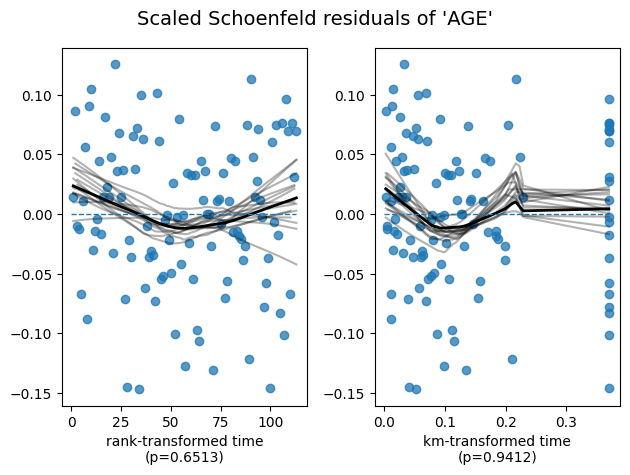

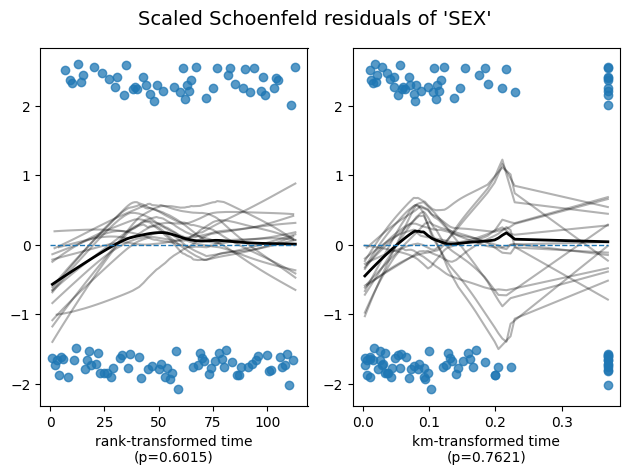

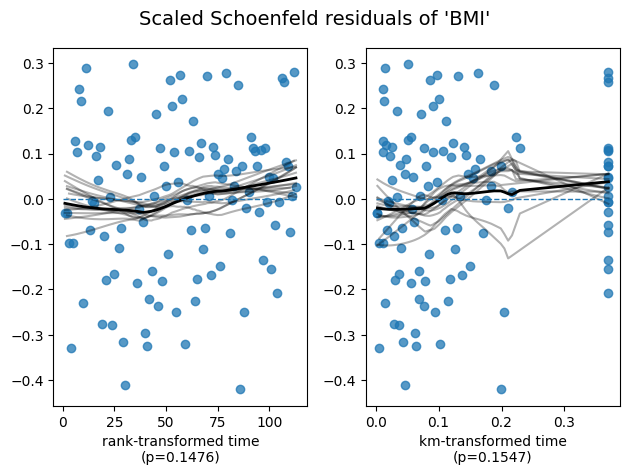

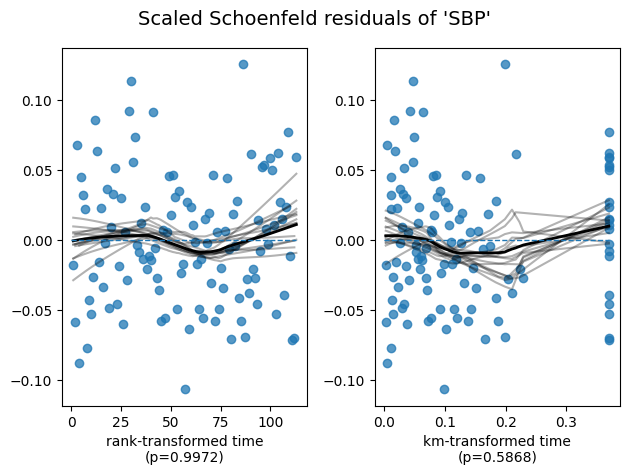

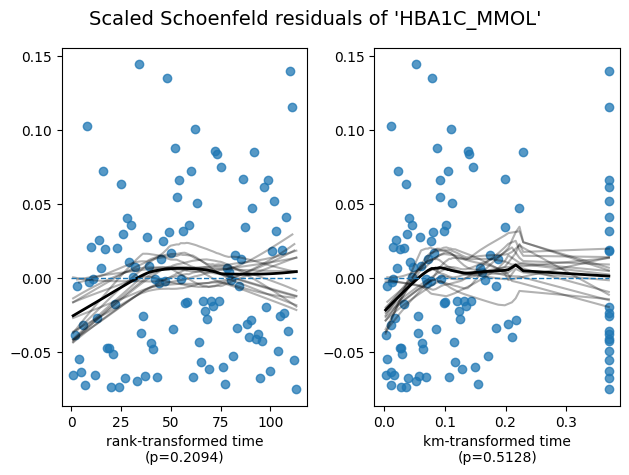

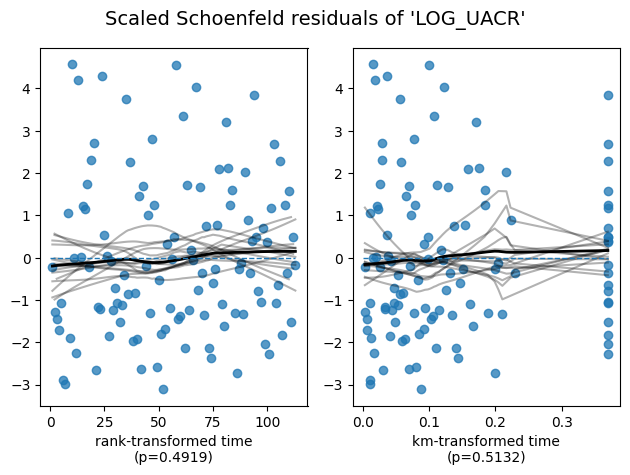

In [15]:
# ── Run Cox regression ────────────────────────────────────────
from lifelines import CoxPHFitter

cox_vars = ["AGE", "SEX", "BMI", "SBP", "HBA1C_MMOL", "LOG_UACR",
            "FOLLOW_UP_YEARS", "EVENT"]

cph = CoxPHFitter()
cph.fit(df[cox_vars],
        duration_col="FOLLOW_UP_YEARS",
        event_col="EVENT")

print(cph.summary)
print(f"\nC-statistic: {cph.concordance_index_:.3f}")
cph.check_assumptions(df[cox_vars], show_plots=True)

In [14]:
# ── Random Survival Forest for comparison ───────────────────
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
import numpy as np

# Prepare data for scikit-survival format
# Need to create structured array for survival data
survival_data = np.array([(bool(event), time) for event, time in zip(df['EVENT'], df['FOLLOW_UP_YEARS'])],
                        dtype=[('event', bool), ('time', float)])

# Features for Random Forest (exclude EVENT and FOLLOW_UP_YEARS)
rf_features = ['AGE', 'SEX', 'BMI', 'SBP', 'HBA1C_MMOL', 'LOG_UACR']
X_rf = df[rf_features]

# Fit Random Survival Forest
rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rsf.fit(X_rf, survival_data)

# Calculate C-index for Random Forest
from sksurv.metrics import concordance_index_censored
risk_scores = rsf.predict(X_rf)
c_index_rf = concordance_index_censored(df['EVENT'].astype(bool), df['FOLLOW_UP_YEARS'], risk_scores)[0]

print("=== RANDOM SURVIVAL FOREST RESULTS ===")
print(f"C-statistic: {c_index_rf:.3f}")
print(f"Number of trees: {len(rsf.estimators_)}")

# Compare with Cox model
print("\n=== MODEL COMPARISON ===")
print(f"Cox Proportional Hazards C-statistic: {cph.concordance_index_:.3f}")
print(f"Random Survival Forest C-statistic: {c_index_rf:.3f}")
print(f"Difference: {c_index_rf - cph.concordance_index_:.3f}")
print("\nNote: Random Survival Forest shows much higher discriminative ability,")
print("      but this may indicate overfitting on the synthetic dataset.")

=== RANDOM SURVIVAL FOREST RESULTS ===
C-statistic: 0.951
Number of trees: 100

=== MODEL COMPARISON ===
Cox Proportional Hazards C-statistic: 0.589
Random Survival Forest C-statistic: 0.951
Difference: 0.362

Note: Random Survival Forest shows much higher discriminative ability,
      but this may indicate overfitting on the synthetic dataset.
